# 순환 신경망 기반 감성 분석 (네이버 영화 리뷰)
1. 데이터 준비
2. 모델 구조 및 학습 설계 (구축)
3. 모델 학습
4. 모델 평가
5. 예측
6. 배포 (저장, 재사용)

## 1. 데이터 준비
    1-1. 데이터 로딩
    1-2. 데이터 전처리
    1-3. 데이터 분리 
    1-4. 학습용 데이터 준비
    1-5. 테스트용 데이터준비 

### 1-1. 데이터 로딩

In [2]:
# naver_movie_review.csv
import pandas as pd
datafile = './data/naver_movie_review.csv'
review_df = pd.read_csv(datafile)
review_df.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [3]:
review_df.label.value_counts()

label
0    100000
1    100000
Name: count, dtype: int64

In [4]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        200000 non-null  int64 
 1   document  199992 non-null  object
 2   label     200000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.6+ MB


### 1-2. 데이터 전처리
- 결측치 제거
- 정제 (한글만 남기고 모두 삭제)
- 중복치 제거
- 형태소 분석기로 토큰화

#### 1-2-1. 결측치 제거

In [5]:
# 결측치 확인
review_df.isnull().sum()

id          0
document    8
label       0
dtype: int64

In [6]:
review_df[review_df.document.isnull()]

,id,document,label
25857,2172111,NaN,1
55737,6369843,NaN,1
110014,1034280,NaN,0
126782,5942978,NaN,0
140721,1034283,NaN,0
155746,402110,NaN,1
157899,5026896,NaN,0
177097,511097,NaN,1


In [7]:
# 결측치 제거
review_df.dropna(inplace=True)
review_df.isnull().sum()

id          0
document    0
label       0
dtype: int64

#### 1-2-2. 정제
* 한글과 공백을 제외한 문자는 공백으로 치환하여 제거
* 한글이 없었던 문장은 공백만 남아있게 되므로, 결측치 삭제 처리 진행 필요

In [8]:
import re
# 한글과 공백 제외하고 모두 공백으로 치환
review_df['clean_review'] = review_df.document.apply(lambda x : re.sub('[^ 가-힣]+', ' ', x))

# 문장의 시작 부분에 있는 공백을 ""으로 치환 
review_df.clean_review = review_df.clean_review.apply(lambda x : re.sub('^ +', '', x))

# 빈 문자열("")은 결측치로 수정
review_df.clean_review = review_df.clean_review.replace('', None)

review_df.head()

,id,document,label,clean_review
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,아 더빙 진짜 짜증나네요 목소리
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나
2,10265843,너무재밓었다그래서보는것을추천한다,0,너무재밓었다그래서보는것을추천한다
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,교도소 이야기구먼 솔직히 재미는 없다 평점 조정
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...


In [9]:
# 결측치 확인
review_df.clean_review.isnull().sum()

np.int64(2177)

In [10]:
# 결측치 제거
review_df.dropna(subset=['clean_review'], inplace=True)

In [11]:
review_df.clean_review.isnull().sum()

np.int64(0)

#### 1-2-3. 중복치 제거

In [12]:
# 중복치 확인
review_df.clean_review.duplicated().sum()

np.int64(6550)

In [13]:
review_df[review_df.clean_review.duplicated()].sort_values(by=['clean_review'])

,id,document,label,clean_review
169301,10230088,가나다라마바사아자차,1,가나다라마바사아자차
9137,9629024,가나다라마바사아자차,1,가나다라마바사아자차
37314,9593066,가나다라마바사아자차,0,가나다라마바사아자차
81436,8522472,가나다라마바사아자차,0,가나다라마바사아자차
154484,8145963,가나다라마바사아자차,0,가나다라마바사아자차
...,...,...,...,...
135586,7204210,흥미진진,1,흥미진진
141061,573619,흥미진진..,1,흥미진진
72688,5153363,힐러리 더프의 매력에 빠지다!!!,1,힐러리 더프의 매력에 빠지다
167827,4052413,힘내세요,0,힘내세요


In [14]:
# 중복치 제거
review_df.drop_duplicates(subset=['clean_review'], inplace=True)
review_df.clean_review.duplicated().sum()

np.int64(0)

In [15]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191265 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            191265 non-null  int64 
 1   document      191265 non-null  object
 2   label         191265 non-null  int64 
 3   clean_review  191265 non-null  object
dtypes: int64(2), object(2)
memory usage: 7.3+ MB


#### 1-2-4. 토큰화

In [16]:
# 형태소 분석기 적용 (Okt 등)
from konlpy.tag import Okt
from tqdm import tqdm
tqdm.pandas()

review_df['tokens'] = review_df.clean_review.progress_apply(Okt().morphs)

100%|██████████| 191265/191265 [03:46<00:00, 843.56it/s]


In [17]:
review_df['tokens_str'] = review_df.tokens.apply(lambda x : ' '.join(x))
review_df.head()

,id,document,label,clean_review,tokens,tokens_str
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,아 더빙 진짜 짜증나네요 목소리,"[아, 더빙, 진짜, 짜증나네요, 목소리]",아 더빙 진짜 짜증나네요 목소리
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,"[흠, 포스터, 보고, 초딩, 영화, 줄, 오버, 연기, 조차, 가볍지, 않구나]",흠 포스터 보고 초딩 영화 줄 오버 연기 조차 가볍지 않구나
2,10265843,너무재밓었다그래서보는것을추천한다,0,너무재밓었다그래서보는것을추천한다,"[너, 무재, 밓었, 다그, 래서, 보는것을, 추천, 한, 다]",너 무재 밓었 다그 래서 보는것을 추천 한 다
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,교도소 이야기구먼 솔직히 재미는 없다 평점 조정,"[교도소, 이야기, 구먼, 솔직히, 재미, 는, 없다, 평점, 조정]",교도소 이야기 구먼 솔직히 재미 는 없다 평점 조정
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...,"[사이, 몬페, 그, 의, 익살스런, 연기, 가, 돋보였던, 영화, 스파이더맨, 에...",사이 몬페 그 의 익살스런 연기 가 돋보였던 영화 스파이더맨 에서 늙어 보이기만 했...


In [18]:
review_df.to_csv(datafile.replace('.csv', '_ing.csv'))

In [19]:
from tqdm import tqdm
test_list = [1] * 10000000
for test in tqdm(test_list):
    test += 1

100%|██████████| 10000000/10000000 [00:00<00:00, 10856782.40it/s]


In [20]:
# 전처리 결과를 저장한 파일 로딩
import pandas as pd
datafile = './data/naver_movie_review_ing.csv'
review_df = pd.read_csv(datafile, index_col=0)
review_df.head()

,id,document,label,clean_review,tokens,tokens_str
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,아 더빙 진짜 짜증나네요 목소리,"['아', '더빙', '진짜', '짜증나네요', '목소리']",아 더빙 진짜 짜증나네요 목소리
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,"['흠', '포스터', '보고', '초딩', '영화', '줄', '오버', '연기'...",흠 포스터 보고 초딩 영화 줄 오버 연기 조차 가볍지 않구나
2,10265843,너무재밓었다그래서보는것을추천한다,0,너무재밓었다그래서보는것을추천한다,"['너', '무재', '밓었', '다그', '래서', '보는것을', '추천', '한...",너 무재 밓었 다그 래서 보는것을 추천 한 다
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,교도소 이야기구먼 솔직히 재미는 없다 평점 조정,"['교도소', '이야기', '구먼', '솔직히', '재미', '는', '없다', '...",교도소 이야기 구먼 솔직히 재미 는 없다 평점 조정
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...,"['사이', '몬페', '그', '의', '익살스런', '연기', '가', '돋보였...",사이 몬페 그 의 익살스런 연기 가 돋보였던 영화 스파이더맨 에서 늙어 보이기만 했...


### 1-3. 데이터 분리
* 정답 데이터의 분포 확인 -> 학습용 데이터와 테스트 데이터로 분리 시 비율 유지 (stratify=y)

In [25]:
# 입력 데이터와 정답데이터 추출  (list)
review_list = list(review_df.tokens_str)
label_list = list(review_df.label)

In [21]:
# label 컬럼의 값별 데이터 수 확인
review_df.label.value_counts()

label
0    95987
1    95278
Name: count, dtype: int64

<Axes: xlabel='label'>

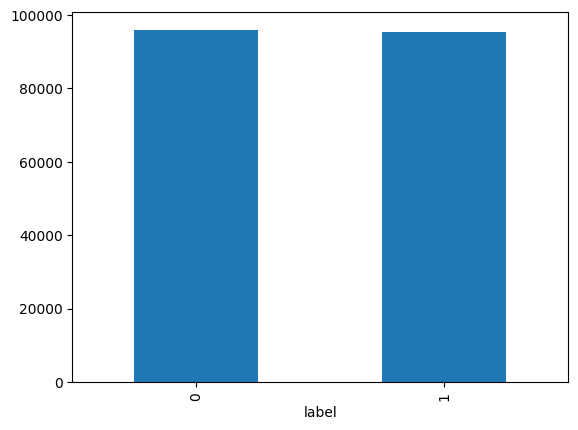

In [23]:
# 막대그래프로 그려보기
review_df.label.value_counts().plot(kind='bar')

In [26]:
# 학습 데이터와 테스트 데이터 분리
from sklearn.model_selection import train_test_split

review_train, review_test, label_train, label_test = train_test_split(review_list, label_list, test_size=0.1)
len(review_train), len(review_test), len(label_train), len(label_test)

(172138, 19127, 172138, 19127)

### 1-4. 학습 데이터 준비 for tensorflow
    1-4-1. Integer Encoding을 위한 tokenizer 생성
    1-4-2. 입력 데이터 Integer Encoding
    1-4-3. 입력 데이터 Padding
    1-4-4. 정답 데이터 원핫인코딩

#### 1-4-1. Integer Encoding을 위한 tokenizer 생성
* num_words = 사용할 단어 수(vocab_size) + 1 (0은 OOV에 할당)

In [28]:
# 단어 수 제한없이 Tokenizer 생성하여 단어 수 확인
from tensorflow .keras.preprocessing.text import Tokenizer
test_tokenizer = Tokenizer()
test_tokenizer.fit_on_texts(review_train)
list(test_tokenizer.word_index.items())[:10]

[('이', 1),
 ('영화', 2),
 ('의', 3),
 ('가', 4),
 ('에', 5),
 ('을', 6),
 ('도', 7),
 ('들', 8),
 ('는', 9),
 ('를', 10)]

In [35]:
from lib.my_utils import word_status_below_threshold
# 등장 빈도수를 threshold로 설정하여 버릴 단어가 차지하는 비율 확인
threshold = 3
word_status_below_threshold(test_tokenizer, threshold)

=== 빈도수가 3번 이상인 단어만 사용하는 경우 ====
전체 단어 : 107,473개 2,255,844번
희귀 단어 : 71,743개 (66.75%) 85,765번 (3.80%)
사용할 단어 : 35,730개 (0.33%)    2,170,079번 (96.20%)


In [36]:
# 단어 수를 제한하여 tokenizer 생성
vocab_size = 40000
num_words = vocab_size + 1
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(review_train)
len(tokenizer.word_index)

107473

#### 1-4-2. 입력 데이터 Integer Encoding
* 제한된 단어에만 index를 부여하므로, 희귀 단어로만 구성된 review는 단어가 0이 되므로 결측치에 해당 -> 결측치 제거

In [39]:
# 입력 데이터 Integer Encoding
encoded_review_train = tokenizer.texts_to_sequences(review_train)
print(encoded_review_train[:10])

[[24251, 15753, 18, 142, 4, 66, 5627], [769, 741, 258, 25, 46, 72, 769, 28661, 2057, 62, 593, 106, 32, 823, 102, 62, 656, 28662, 41, 61, 71, 146, 685, 296, 1180, 1319, 290], [1, 1788, 74, 6, 233, 3584, 1319, 311, 15754, 1086, 8631], [9334, 677, 4167, 35731, 367, 8324], [6477, 686, 1209, 2, 15755, 5, 1979, 28663, 918, 211, 4613, 132, 1209, 42, 358, 2240, 278, 1], [52, 64, 153, 3749, 49, 1, 255, 360, 419, 1, 64, 24252, 48, 17219, 419, 7538, 960, 14488, 27, 3240, 419, 1, 13481], [14489, 249, 4308, 249, 35732, 8058], [2, 240, 240, 3, 4, 226, 28664, 1039, 28665, 3, 301, 405, 16, 24253, 184, 2587, 1, 301, 75, 51, 364, 6478, 10201, 6342], [27, 1253, 12, 425], [897, 3, 4969, 3808, 3, 4246, 35733, 3, 5359]]


In [43]:
train_df = pd.DataFrame()
train_df['review'] = encoded_review_train
train_df['label'] = label_train
train_df.review.apply(lambda x : None if len(x) == 0 else x)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172138 entries, 0 to 172137
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   review  172138 non-null  object
 1   label   172138 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.6+ MB


In [44]:
# 길이가 0인 리뷰의 index 추출
null_index = [index for index, review in enumerate(encoded_review_train) if len(review) < 1]
len(null_index)

357

In [45]:
# 길이가 0인 리뷰가 있는 경우, 길이가 1 이상인 리뷰로 학습데이터 재구성
new_review_train = [review for index, review in enumerate(encoded_review_train) if index not in null_index]
new_label_train = [label for index, label in enumerate(label_train) if index not in null_index]
len(new_review_train), len(new_label_train)

(171781, 171781)

#### 1-4-3. 입력 데이터 padding
* 입력 데이터의 길이(max_len)를 정하여 padding

array([[<Axes: title={'center': '0'}>]], dtype=object)

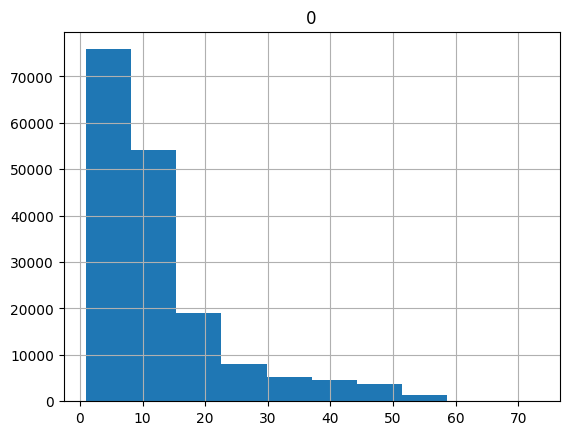

In [46]:
# 리뷰 길이 분포 확인 (히스토그램 그려보기)
len_df = pd.DataFrame([len(review) for review in new_review_train])
len_df.hist()

In [47]:
# 최대, 최소, 평균 등 정보 확인
len_df.describe()

,0
count,171781.000000
mean,12.682538
std,10.649160
min,1.000000
25%,6.000000
50%,9.000000
75%,15.000000
max,73.000000


In [50]:
from lib.my_utils import text_len_status_below_maxlen
# 길이가 max_len 이하인 데이터의 비중 확인
max_len = 50
text_len_status_below_maxlen(new_review_train, max_len)

텍스트의 토근 수가 50 이하인 텍스트 : 169,996개 (98.96)


In [51]:
# max_len 길이로 입력 데이터 padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_X = pad_sequences(new_review_train, maxlen=max_len)
len(train_X), train_X[:2]

(171781,
 array([[    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0, 24251, 15753,
            18,   142,     4,    66,  5627],
        [    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,   769,   741,   258,    25,
            46,    72,   769, 28661,  2057,    62,   593,   106,    32,
           823,   102,    62,   656, 28662,    41,    61,    71,   146,
           685,   296,  1180,  1319,   290]], dtype=int32))

#### 1-4-4. 정답 데이터 one-hot encoding

In [52]:
from tensorflow.keras.utils import to_categorical

train_y = to_categorical(new_label_train)
len(train_y), train_y[:2]

(171781,
 array([[1., 0.],
        [1., 0.]]))

### 1-5. 테스트 데이터 준비
    1-5-1. 입력 데이터 Integer Encoding (결측치제거) 
    1-5-2. 입력 데이터 padding
    1-5-3. 정답 데이터 one-hot encoding

In [53]:
# 입력 데이터 Integer Encoding
encoded_review_test = tokenizer.texts_to_sequences(review_test)
print(encoded_review_test[:2])

[[121, 1463, 20, 46, 3089, 1463, 9, 4332, 3112], [1353, 133, 11430, 133, 14, 8, 39, 1066, 49, 6, 648, 33832, 13191, 881, 295, 1353, 53, 8, 23, 9, 37, 5175, 7517, 133, 2753, 53, 30, 116, 1389, 4, 571, 328, 171, 4, 802]]


In [54]:
# 길이가 0인 리뷰의 index 추출 -> 있으면 길이가 1 이상인 리뷰만으로 테스트 데이터 재구성 
null_index = [index for index, review in enumerate(encoded_review_test) if len(review) == 0]
len(null_index)

57

In [55]:
new_review_test = [review for index, review in enumerate(encoded_review_test) if index not in null_index]
new_label_test = [label for index, label in enumerate(label_test) if index not in null_index]

In [56]:
# 입력 데이터 padding (new_review_test)
test_X = pad_sequences(new_review_test, maxlen=max_len)
len(test_X), test_X[:2]

(19070,
 array([[    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,   121,  1463,    20,    46,
          3089,  1463,     9,  4332,  3112],
        [    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,  1353,   133, 11430,
           133,    14,     8,    39,  1066,    49,     6,   648, 33832,
         13191,   881,   295,  1353,    53,     8,    23,     9,    37,
          5175,  7517,   133,  2753,    53,    30,   116,  1389,     4,
           571,   328,   171,     4,   802]], dtype=int32))

In [58]:
# 정답 데이터 one-hot encoding (new_label_test)
test_y = to_categorical(new_label_test)
len(test_y), test_y[:5]

(19070,
 array([[0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [1., 0.]]))

## 2. 모델 구축 및 컴파일

In [59]:
# 신경망 구조 설계
from tensorflow.keras.layers import Embedding, LSTM, Dense

input_units = num_words # 사용한 feature 수 = 단어 수
embedding_dim = 32
lstm_units = 32
dense_units = 16
output_units = 2 # 분류의 수 2개

rnn_model = [
    Embedding(input_units, embedding_dim, input_length=max_len), 
    # input_length는 지정하지 않아도 학습 가능함
    # 배포 후 예측으로 사용시에도 padding 필요 -> padding 할 max_len 정보를 model에 저장해 놓기 위해 파라미터로 전달
    LSTM(lstm_units),
    Dense(dense_units, activation='tanh'),
    Dense(output_units, activation='softmax')
]

c:\Users\user\anaconda3\envs\aiservice26\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [60]:
# 신경망 구조 생성
from tensorflow.keras.models import Sequential

model = Sequential(rnn_model)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [61]:
# 모델 학습 설계
from tensorflow.keras.optimizers import RMSprop
model.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer=RMSprop(learning_rate=0.001))

In [62]:
# EarlyStopping, ModelCheckpoint callback 객체 설정
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

es = EarlyStopping(monitor='val_loss', mode='min', patience=3, verbose=1)
checkpoint_file = './model/best_model.h5'
mc = ModelCheckpoint(checkpoint_file, monitor='val_loss', mode='mix', save_best_only=True)

C:\Users\user\AppData\Local\Temp\ipykernel_15740\2914918674.py:7: UserWarning: ModelCheckpoint mode 'mix' is unknown, fallback to auto mode.
  mc = ModelCheckpoint(checkpoint_file, monitor='val_loss', mode='mix', save_best_only=True)


## 3. 모델 학습

In [63]:
# 모델 학습
history = model.fit(train_X, train_y, epochs=20, batch_size=128, validation_split=0.1, callbacks=[es, mc])

Epoch 1/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7262 - loss: 0.5147

1208/1208 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.7262 - loss: 0.5146 - val_accuracy: 0.8364 - val_loss: 0.3676
Epoch 2/20
1207/1208 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8570 - loss: 0.3341

1208/1208 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8570 - loss: 0.3341 - val_accuracy: 0.8437 - val_loss: 0.3521
Epoch 3/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8724 - loss: 0.3042

1208/1208 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8724 - loss: 0.3042 - val_accuracy: 0.8477 - val_loss: 0.3494
Epoch 4/20
1206/1208 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8803 - loss: 0.2889

1208/1208 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8803 - loss: 0.2889 - val_accuracy: 0.8473 - val_loss: 0.3447
Epoch 5/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8890 - loss: 0.2717 - val_accuracy: 0.8506 - val_loss: 0.3503
Epoch 6/20
1204/1208 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8984 - loss: 0.2533

1208/1208 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8984 - loss: 0.2534 - val_accuracy: 0.8541 - val_loss: 0.3412
Epoch 7/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9061 - loss: 0.2393 - val_accuracy: 0.8531 - val_loss: 0.3482
Epoch 8/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9148 - loss: 0.2225 - val_accuracy: 0.8530 - val_loss: 0.3498
Epoch 9/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9212 - loss: 0.2074 - val_accuracy: 0.8548 - val_loss: 0.3608
Epoch 9: early stopping


## 4. 모델 평가

In [ ]:
# 저장된 모델 로딩하여, 테스트 데이터로 평가


In [ ]:
# predict로 테스트 데이터의 예측값 구기기


In [ ]:
# sklearn의 classification_report()로 평가 결과 확인


## 5. 예측

In [ ]:
# 입력된 리뷰에 대한 긍부정 판단 함수


In [ ]:
# 함수 테스트
reviews = [
    '이 영화 개꿀잼 ㅋㅋㅋ',
    '하품만 나온다',
    '이 영화 핵노잼 ㅠㅠ',
    '이딴게 영화냐 ㅉㅉ',
    '와 개쩐다',
    '감독 뭐하는 놈이냐',
    '정말 세계관 최강자들의 영화다'
]



## 6. 배포 (모델 저장 및 재사용)
    6-1. 모델 저장
    6-2. SentimentAnalyzer 클래스 구현
        *  저장된 모델 로딩 및 사용

### 6-1. 모델 저장 

In [ ]:
# keras 학습 모델저장 


In [ ]:
# Integer Encoding을 위한 파이썬 객체 직렬화 (encoder)


### 6-2. SentimentAnalyzer 클래스 구현
- 객체 생성 시 예측 모델, Integer Encoder 로딩
- 한국어 형태소 분석기 정의
- 입력된 리뷰의 긍부정 판단 함수